In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100



## 2. Load the Dataset

In [4]:
# Load the Titanic dataset
df = pd.read_csv("data/titanic.csv")

# Display basic information about the dataset
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(10)

Dataset shape: 891 rows, 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## Column Descriptions

| Column | Description |
|---|---|
| PassengerId | ID jedes Passagier |
| Survived | 0 = nicht Überlebt, 1 = Überlebt |
| Pclass | Ticket Klasse: 1 = Erste, 2 = Zweite, 3 = Dritte |
| Name | Passagier Name |
| Sex | Geschlecht |
| Age | Alter |
| SibSp | Anzahl von Geschwister/Ehepartner an Bord |
| Parch | Anzahl der Eltern/Kinder an Bord |
| Ticket | Ticket Nummer |
| Fare | Fahrpreis |
| Cabin | Kabinennummer |
| Embarked | Einschiffungshafen: C = Cherbourg, Q = Queenstown, S = Southampton |

## 3. Dataset Overview

In [5]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# Statistical summary of numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# Statistical summary of categorical columns
df.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


## 4. Missing Values Analysis

In [8]:
# Missing values in each column
missing_dataframe = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing_dataframe[missing_dataframe["Missing Count"] > 0]
print(missing)

          Missing Count  Missing %
Age                 177      19.87
Cabin               687      77.10
Embarked              2       0.22


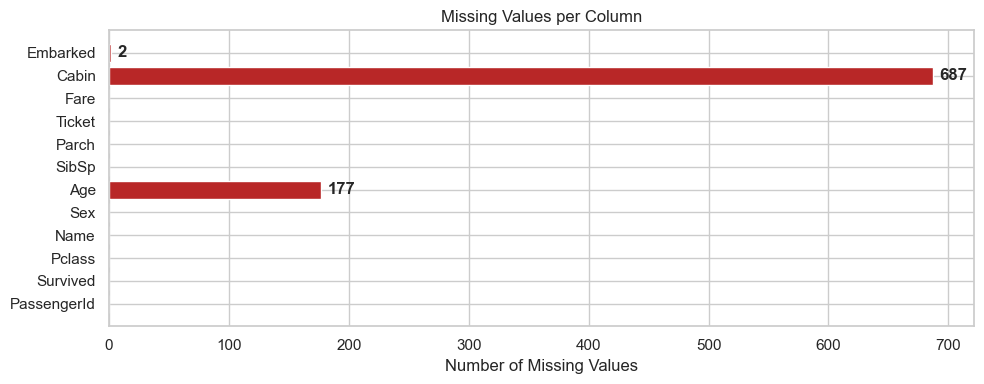

In [9]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 4))

# Color bars red if there are missing values, green otherwise
colors = ["#b82727" if df[col].isnull().any() else "#2ecc71" for col in df.columns]

# Bar plot of missing values
ax.barh(df.columns, df.isnull().sum(), color=colors)
ax.set_xlabel("Number of Missing Values")
ax.set_title("Missing Values per Column")

# Add text labels for missing counts
for i, v in enumerate(df.isnull().sum()):
    if v > 0:
        ax.text(v + 5, i, str(v), va="center", fontweight="bold")
plt.tight_layout()
plt.show()

**Wichtigste Beobachtungen:**

- Cabin hat ~77% fehlende Werte — Zu viel damit es vertraulich ist, am besten droppen
- Age hat ~20% fehlende Werte — Nutze Median zum Auffüllen
- Embarked hat nur 2 fehlende Werte — Leicht zu füllen


## 5. Target Variable Analysis

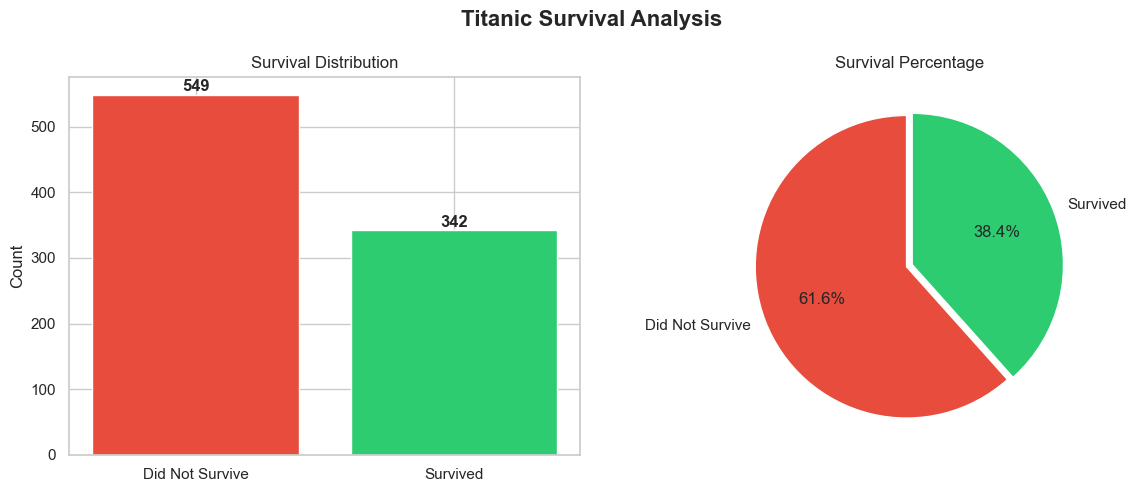

Survival Rate: 38.38%
Death Rate: 61.62%


In [10]:
# Survival distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot for survival
survival_counts = df["Survived"].value_counts()
axes[0].bar(["Did Not Survive", "Survived"], survival_counts, color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Survival Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(survival_counts):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# Pie chart for survival
axes[1].pie(survival_counts, labels=["Did Not Survive", "Survived"], autopct="%1.1f%%", colors=["#e74c3c", "#2ecc71"],startangle=90,explode=(0.02, 0.02))
axes[1].set_title("Survival Percentage")

plt.suptitle("Titanic Survival Analysis", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Survival Rate: {df['Survived'].mean() * 100:.2f}%")
print(f"Death Rate: {100 - df['Survived'].mean() * 100:.2f}%")



Vergleichsweise viel höhere Sterberate.

## 6. Univariate Analysis — Numerical Features

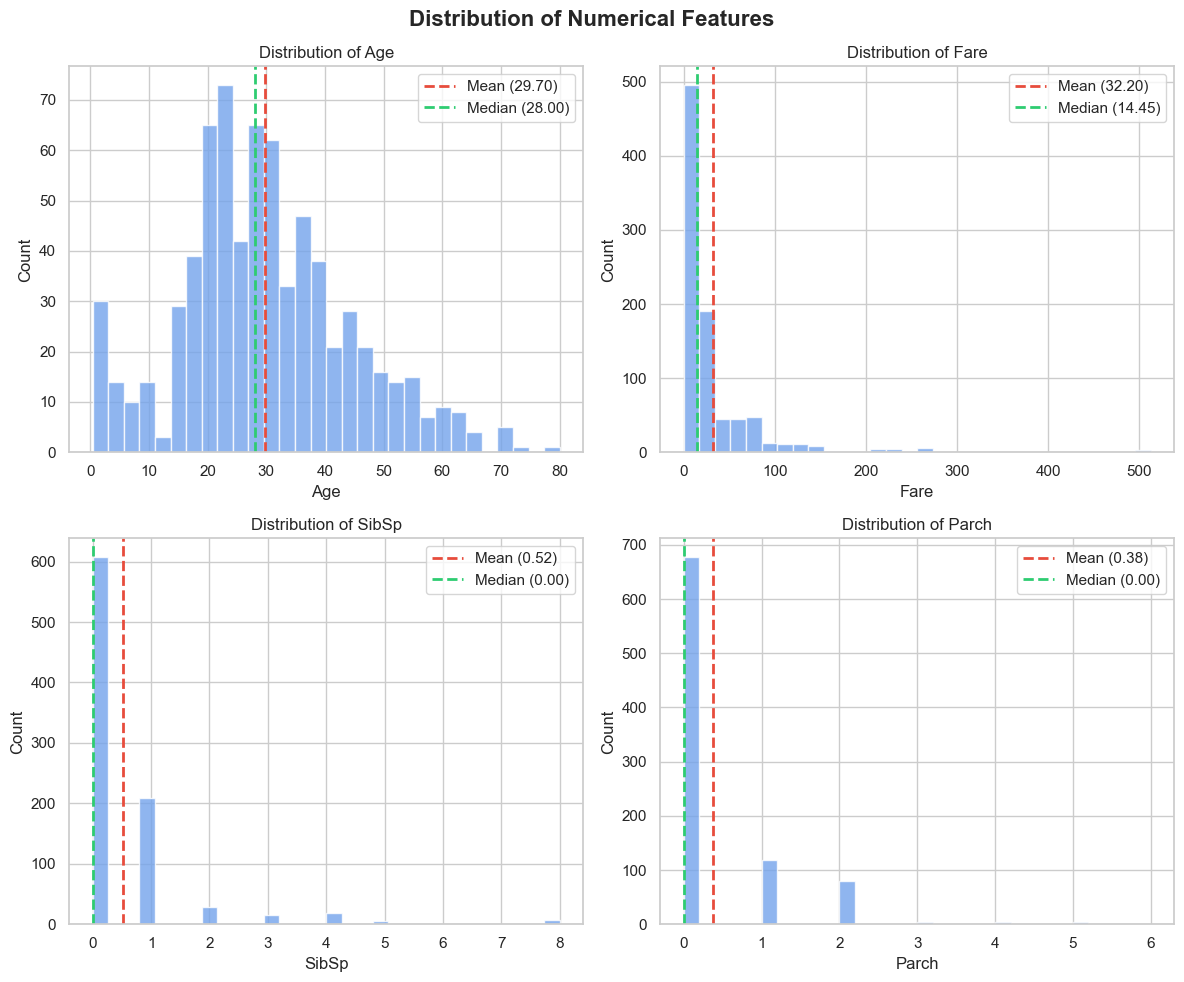

In [11]:
# numerical columns
numerical_cols = ["Age", "Fare", "SibSp", "Parch"]
# oder als numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Histograms for numerical features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# Make axes a flat array for easy iteration
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=30, color="#73a3eb", edgecolor="white", alpha=0.8)
    axes[i].axvline(df[col].mean(), color="#e74c3c", linestyle="dashed", linewidth=2, label=f"Mean ({df[col].mean():.2f})")
    axes[i].axvline(df[col].median(), color="#2ecc71", linestyle="dashed", linewidth=2, label=f"Median ({df[col].median():.2f})")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend()

plt.suptitle("Distribution of Numerical Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


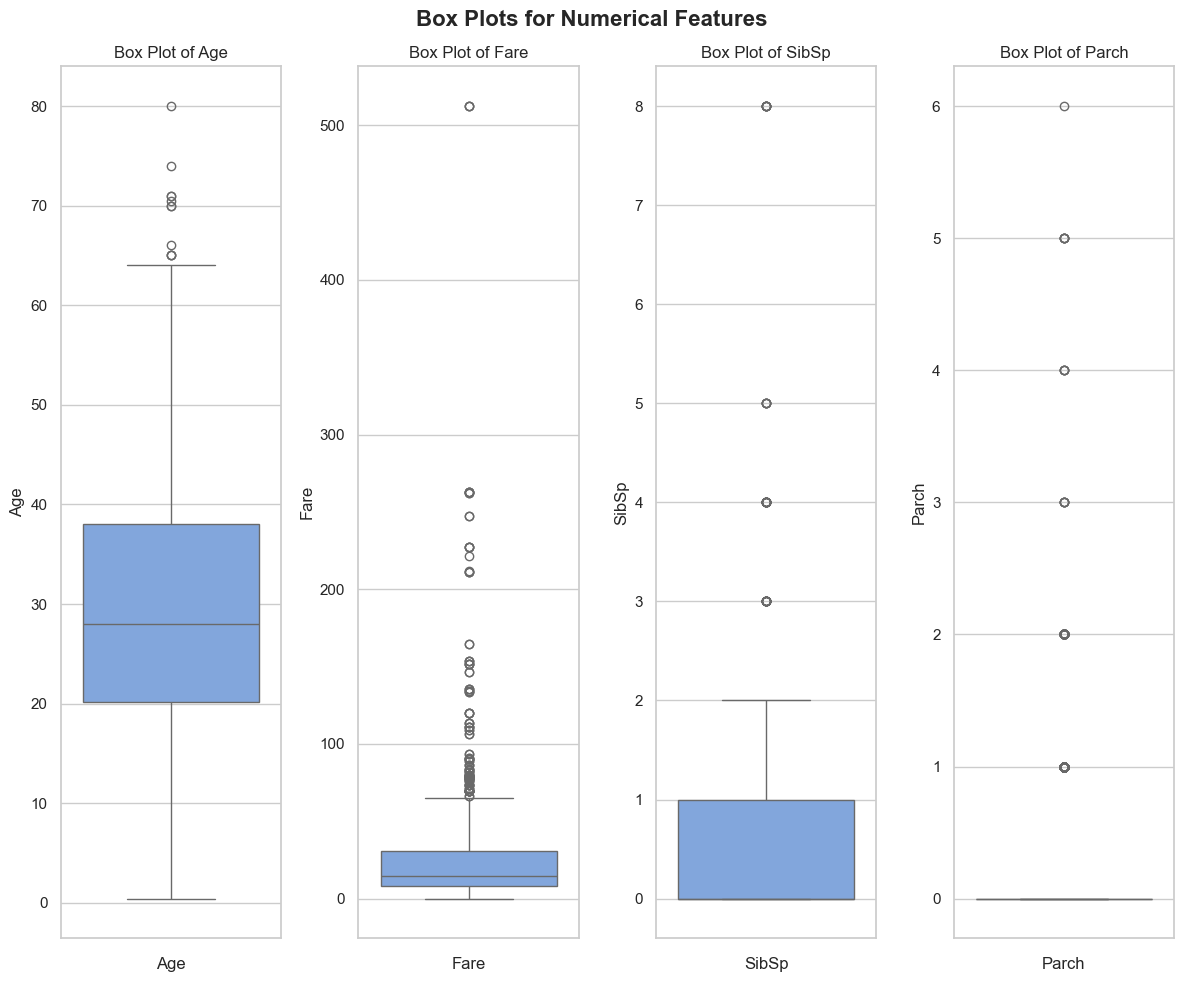

In [12]:
# Box plots for outliers
fig, axes = plt.subplots(1, 4, figsize=(12, 10))

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#73a3eb")
    axes[i].set_title(f"Box Plot of {col}")
    axes[i].set_xlabel(col)

plt.suptitle("Box Plots for Numerical Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

**Erkennungen**
- **Alter:** Relativ Normalverteilt mit Mittelwert um ca. 30. Vereinzelte Ausreißer bei höheren Altersgruppen.
- **Fahrpreis:** Stark nach Rechts/Unten gezogen mit deutlichen Ausreißern. Einige wenige Passagiere zahlten sehr hohe Fahrpreise.
- **Anzahl der Geschwister und Ehepartner und Anzahl der Eltern/Kinder an Bord:** Die meisten Passagiere reisten allein oder mit 1-2 Familienmitgliedern.

## 7. Univariate Analysis — Categorical Features

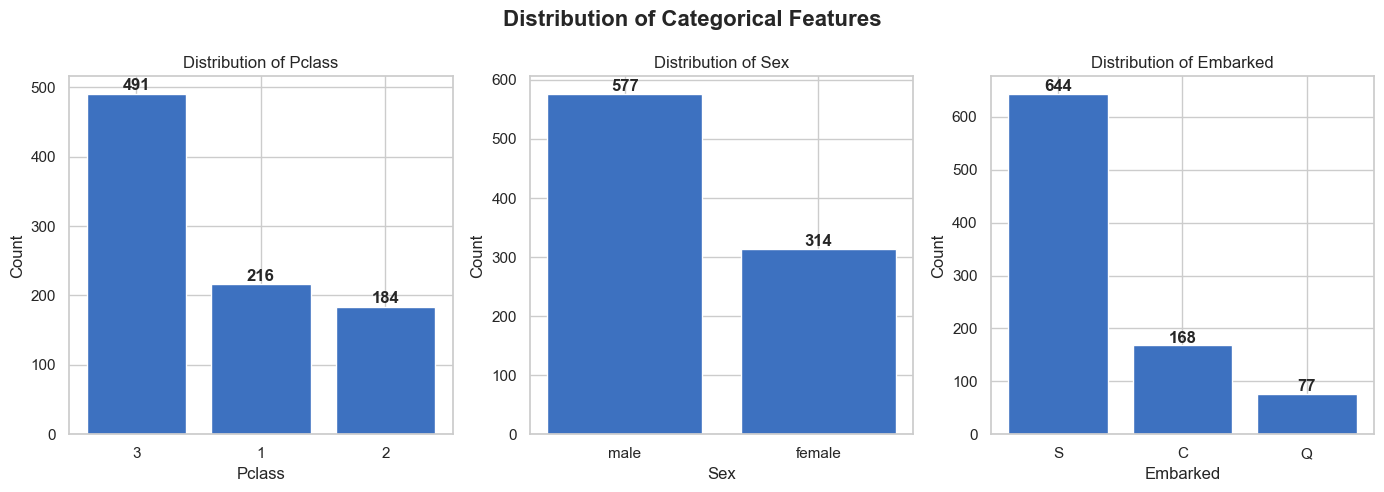

In [13]:
# Distribution of categorical features
categorical_cols = ["Pclass", "Sex", "Embarked"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, color="#3d71c0", edgecolor="white")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 5, str(v), ha="center", fontweight="bold")

plt.suptitle("Distribution of Categorical Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

**Erkentnisse**:
- **Pclass**: Großteil aller Passagiere waren in der dritten Klasse.
- **Sex**: Bei weitem mehr Männliche als Weibliche Passagiere.
- **Embarked**: Die meisten Passagiere sind in Southampton (S) eingestiegen.

## 8. Bivariate Analysis — Survival vs Features

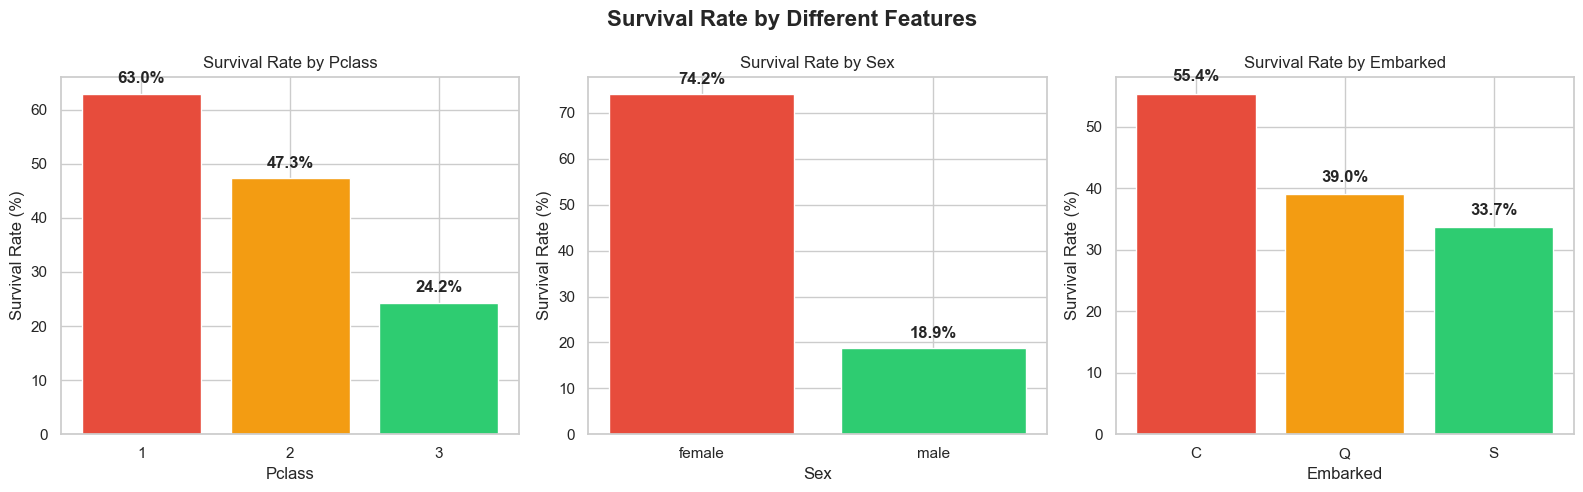

In [14]:
# Survival rate by different features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Survival rate by Pclass
survival_by_pclass = df.groupby("Pclass")["Survived"].mean() * 100
axes[0].bar(survival_by_pclass.index.astype(str), survival_by_pclass.values, color=["#e74c3c", "#f39c12", "#2ecc71"])
axes[0].set_title("Survival Rate by Pclass")
axes[0].set_xlabel("Pclass")
axes[0].set_ylabel("Survival Rate (%)")
for i, v in enumerate(survival_by_pclass.values):
    axes[0].text(i, v + 2, f"{v:.1f}%", ha="center", fontweight="bold")

# Survival by Sex
survival_by_sex = df.groupby("Sex")["Survived"].mean() * 100
axes[1].bar(survival_by_sex.index, survival_by_sex.values, color=["#e74c3c", "#2ecc71"])
axes[1].set_title("Survival Rate by Sex")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Survival Rate (%)")
for i, v in enumerate(survival_by_sex.values):
    axes[1].text(i, v + 2, f"{v:.1f}%", ha="center", fontweight="bold")

# Survival by Embarked
survival_by_embarked = df.groupby("Embarked")["Survived"].mean() * 100
axes[2].bar(survival_by_embarked.index.astype(str), survival_by_embarked.values, color=["#e74c3c", "#f39c12", "#2ecc71"])
axes[2].set_title("Survival Rate by Embarked")
axes[2].set_xlabel("Embarked")
axes[2].set_ylabel("Survival Rate (%)")
for i, v in enumerate(survival_by_embarked.values):
    axes[2].text(i, v + 2, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Survival Rate by Different Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

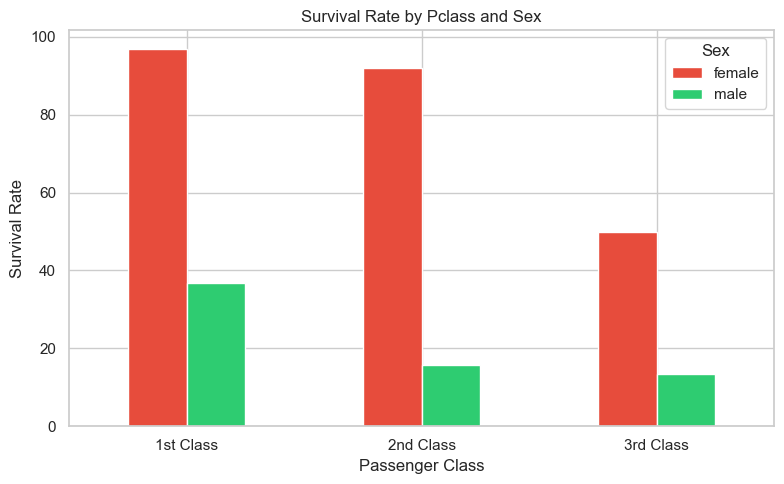

In [17]:
# Survival rate by Pclass and Sex
fig, ax = plt.subplots(figsize=(8,5))
survival_grouped = df.groupby(["Pclass", "Sex"])["Survived"].mean().unstack() * 100
survival_grouped.plot(kind="bar", ax=ax, color=["#e74c3c", "#2ecc71"])
ax.set_title("Survival Rate by Pclass and Sex")
ax.set_ylabel("Survival Rate")
ax.set_xlabel("Passenger Class")
ax.legend(title="Sex")
ax.set_xticklabels(["1st Class", "2nd Class", "3rd Class"], rotation=0)
plt.tight_layout()
plt.show()

**Wichtigste Beobachtungen**:
- **Frauen haben eine viel höhere Überlebensrate** (74%) im Vergleich zu Männern (19%) - "Kinder und Frauen zu erst"
- **Passagiere der ersten Klasse** hatten eine höhere Überlebensrate als die anderen Klassen
- **Cherbourg Passagiere** hatten die höchste Überlebensrate, wahrscheinlich gab es mehr Frauen oder mehr erste Klasse Passagiere


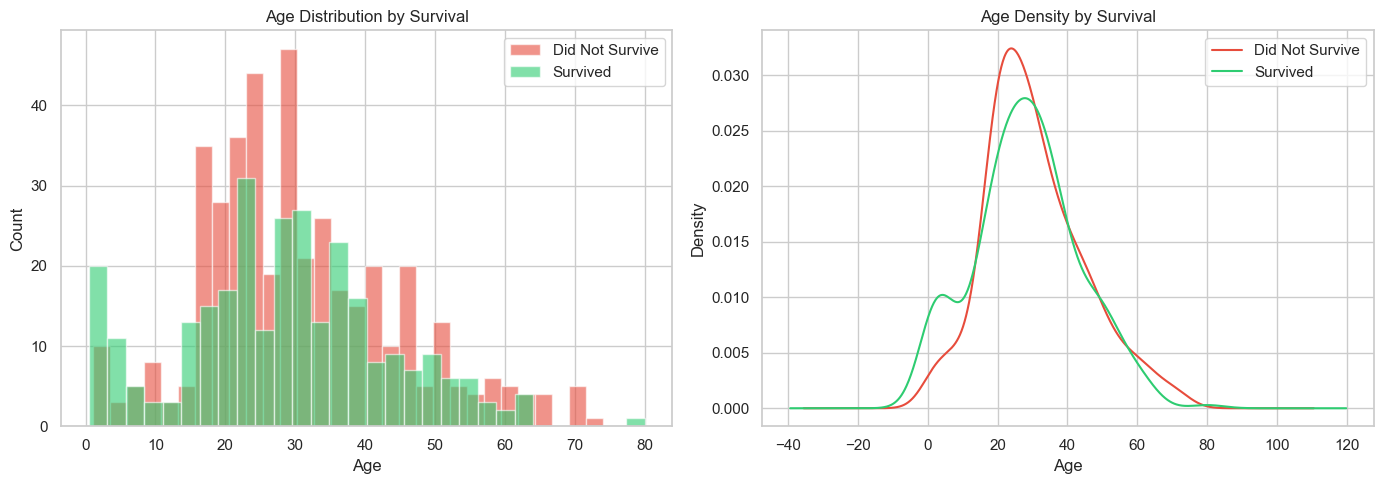

In [24]:
# Age distribution by survival
fig, axes = plt.subplots(1,2, figsize=(14, 5))

# Overlayed histograms
axes[0].hist(df[df["Survived"] == 0]["Age"].dropna(), bins=30, color="#e74c3c", alpha=0.6, label="Did Not Survive")
axes[0].hist(df[df["Survived"] == 1]["Age"].dropna(), bins=30, color="#2ecc71", alpha=0.6, label="Survived")
axes[0].set_title("Age Distribution by Survival")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].legend()

# KDE plot
df[df["Survived"] == 0]["Age"].dropna().plot(kind="kde", ax=axes[1], color="#e74c3c", label="Did Not Survive")
df[df["Survived"] == 1]["Age"].dropna().plot(kind="kde", ax=axes[1], color="#2ecc71", label="Survived")
axes[1].set_title("Age Density by Survival")
axes[1].set_xlabel("Age")
axes[1].legend()

plt.tight_layout()
plt.show()

C:\Users\Gian\AppData\Local\Temp\ipykernel_17056\3041307689.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Survived", y="Fare", data=df, palette=["#e74c3c", "#2ecc71"], ax=ax)
C:\Users\Gian\AppData\Local\Temp\ipykernel_17056\3041307689.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Did Not Survive", "Survived"])


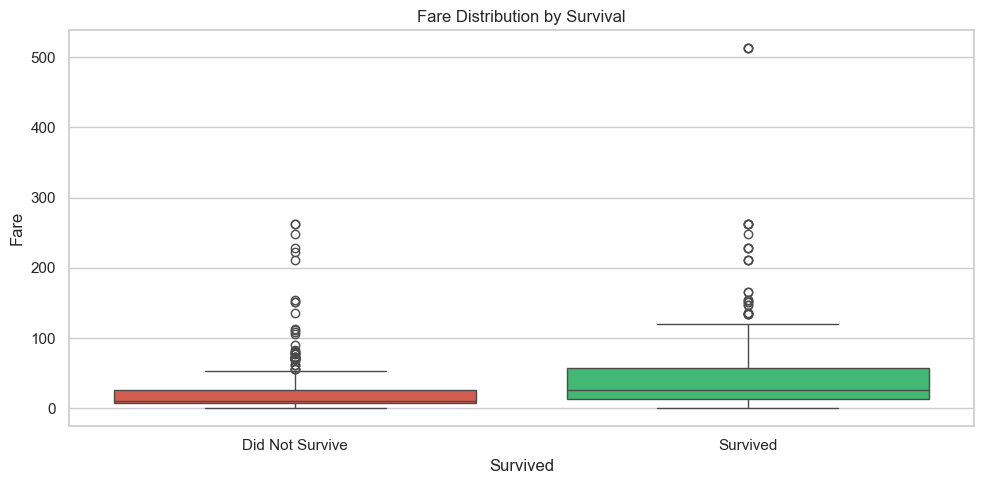

Average fare — Survived: $48.40
Average fare — Did Not Survive: $22.12


In [25]:
# Fare distribution by survival
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(x="Survived", y="Fare", data=df, palette=["#e74c3c", "#2ecc71"], ax=ax)
ax.set_xticklabels(["Did Not Survive", "Survived"])
ax.set_title("Fare Distribution by Survival")
ax.set_ylabel("Fare")
plt.tight_layout()
plt.show()

print(f"Average fare — Survived: ${df[df['Survived']==1]['Fare'].mean():.2f}")
print(f"Average fare — Did Not Survive: ${df[df['Survived']==0]['Fare'].mean():.2f}")

**Beobachtungen**:
- Kinder (Alter < 10) haben eine erkennbar höhere Überlebensrate
- Passagiere die Überlebt haben, haben auch im durchschnitt mehr bezahlt (Höherer Preis = Höhere Klasse)


## 9. Family Size Analysis

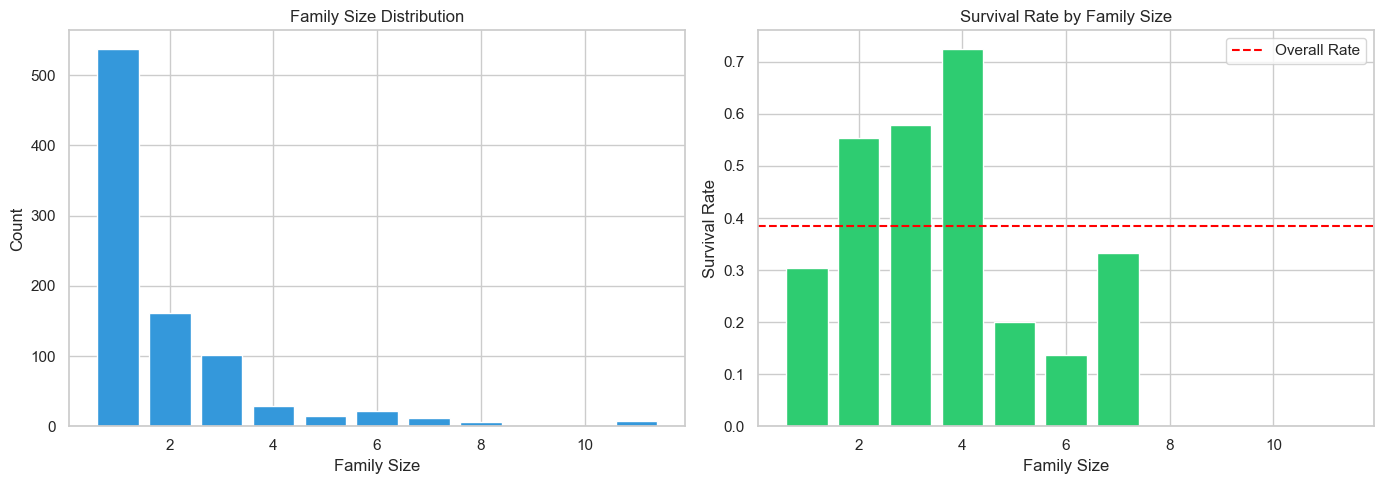

In [26]:
# Create FamilySize feature
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Family size distribution
family_counts = df["FamilySize"].value_counts().sort_index()
axes[0].bar(family_counts.index, family_counts.values, color="#3498db", edgecolor="white")
axes[0].set_title("Family Size Distribution")
axes[0].set_xlabel("Family Size")
axes[0].set_ylabel("Count")

# Survival rate by family size
survival_by_family = df.groupby("FamilySize")["Survived"].mean()
axes[1].bar(survival_by_family.index, survival_by_family.values, color="#2ecc71", edgecolor="white")
axes[1].set_title("Survival Rate by Family Size")
axes[1].set_xlabel("Family Size")
axes[1].set_ylabel("Survival Rate")
axes[1].axhline(y=df["Survived"].mean(), color="red", linestyle="--", label="Overall Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

**Beobachtung**:
- Passagiere mit kleinen Familien (2-4 Mitglieder) hatten die höchsten Überlebensraten
- Solo Passagiere oder große Familien hatten kleine Überlebensraten

# 10. Correlation Analysis

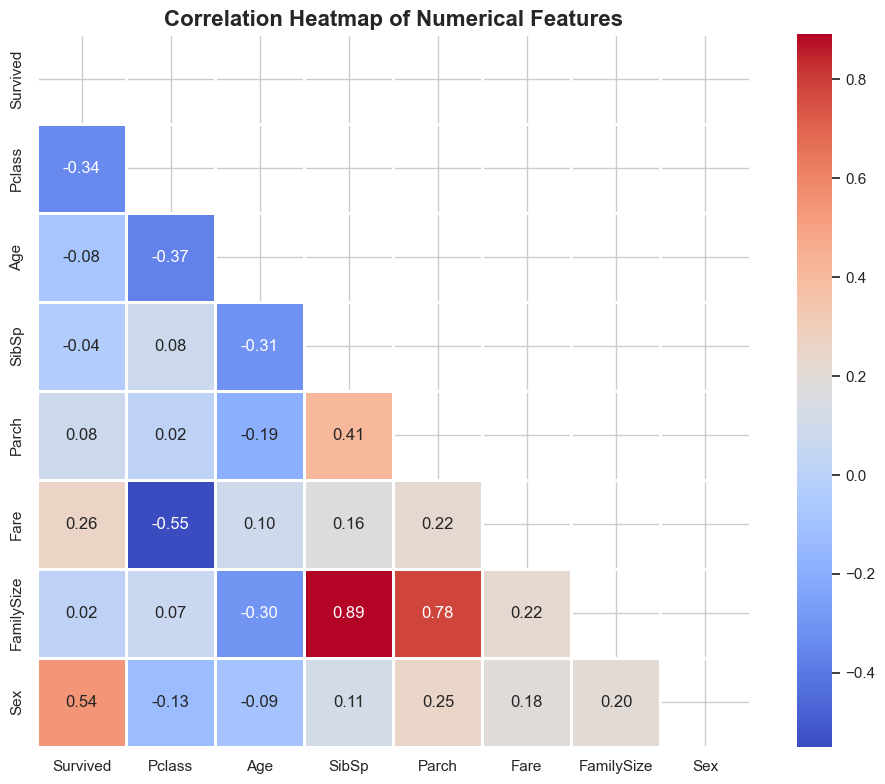

In [28]:
# Correlation heatmap for numerical features
numerical_df = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize"]].copy()
numerical_df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

corr = numerical_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",  square=True, linewidths=1, ax=ax)
ax.set_title("Correlation Heatmap of Numerical Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

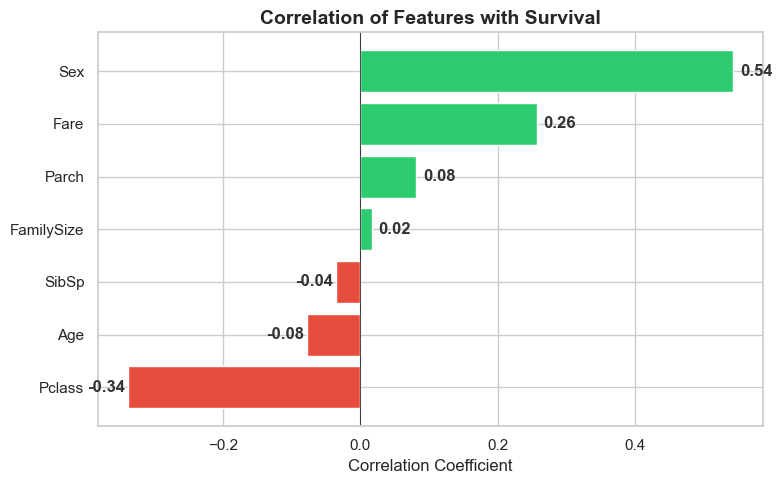

In [34]:
# Correlation with target
target_corr = corr["Survived"].drop("Survived").sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e74c3c" if val < 0 else "#2ecc71" for val in target_corr]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_title("Correlation of Features with Survival", fontsize=14, fontweight="bold")
ax.set_xlabel("Correlation Coefficient")
ax.axvline(x=0, color="black", linewidth=0.5)
for i, v in enumerate(target_corr.values):
    ax.text(v + (0.01 if v > 0 else -0.06), i, f"{v:.2f}", va="center", fontweight="bold", color="#333")
plt.tight_layout()
plt.show()


**Wichtigste Zusammenhänge**:
- **Geschlecht**: Frauen haben die größte positive Korrelation - Weiblich zu sein erhöht die Überlebenschance deutlich
- **Fahrpreis**: positive Korrelation – höhere Fahrpreise (höhere Klasse) führten zu besseren Überlebenschancen.
- **Reiseklasse**: negative Korrelation – niedrigere Klassennummer (1. Klasse) = höhere Überlebenschancen.
- **Alter**: leichte negative Korrelation – jüngere Passagiere hatten etwas bessere Überlebenschancen.

# 11. Summary of EDA Findings

## Column Descriptions

| Erkenntnis | Detail |
|---|---|
| Fehlende Daten | Kabine (77 %), Alter (20 %), Eingeschifft (<1 %) |
| Geschlecht ist der stärkste Prädiktor | Frauen überlebten mit einer Wahrscheinlichkeit von ca. 74 %, Männer mit ca. 19 %. |
| Alter | Kinder hatten höhere Überlebensrate; Ältere Menschen schlechtere |
| Fahrpreise | Überlebende haben deutlich höhere Preise gezahlt |
| Familien Größe | Klein Familien (2-4) hatten die besten Überlebensraten |
| Einschiffung | Cherbourg hat mehr Überlebende (Höhere Klasse) |
| Klasse ist Relevant | Erste Klasse hat 63% Überlebensrate vs Dritte Klasse 24% |
| Klassenungleichgewicht | ca. 38% Überlebten, ca. 62% Überlebten nicht |

